<center>
    <h1>
    Exploration
    </h1>
</center>

In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
#
# import utilitaires
#
%matplotlib inline

import audioread
import librosa as rosa
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset BirdCLEF
raw_df = pd.read_csv(config.get_csv_filename(DatasetType.RAW))

In [5]:
print("Information sur le data:", config.dataset.data_description_url)

Information sur le data: https://www.kaggle.com/competitions/birdclef-2023/data


In [6]:
print("Dataset shape:", raw_df.shape)

print()

print("Types")
display(raw_df.dtypes.to_frame().T)

Dataset shape: (16941, 12)

Types


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,object,object,object,float64,float64,object,object,object,object,float64,object,object


In [7]:
#
# secondary_labels et type sont des listes
# valider que le parsing est bien ce qu'on pense
#
print("Type element 'secondary_labels':", type(raw_df.loc[0, "secondary_labels"]))
print("Type element 'type':", type(raw_df.loc[0, "type"]))

Type element 'secondary_labels': <class 'str'>
Type element 'type': <class 'str'>


<div class="answer">

On peut voir que la lecture du .csv n'est pas correcte. On devrait avoir une liste.

In [8]:
#
# corriger secondary_labels et type; ils sont des listes
#
if isinstance(raw_df.loc[0, "secondary_labels"], str):
    from ast import literal_eval

    raw_df["secondary_labels"] = raw_df["secondary_labels"].apply(literal_eval)
    raw_df["type"] = raw_df["type"].apply(literal_eval)

print()

print("Affichage succint")
display(raw_df.head())


Affichage succint


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,abethr1,[],[song],4.3906,38.2788,Turdus tephronotus,African Bare-eyed Thrush,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/128013,abethr1/XC128013.ogg
1,abethr1,[],[call],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363501,abethr1/XC363501.ogg
2,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363502,abethr1/XC363502.ogg
3,abethr1,[],[song],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/363503,abethr1/XC363503.ogg
4,abethr1,[],"[call, song]",-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,4.5,https://www.xeno-canto.org/363504,abethr1/XC363504.ogg


Stat. generale pour 'type'


,count,mean,std,min,25%,50%,75%,max
0,399.0,63.255639,506.758959,1.0,1.0,1.0,2.0,6808.0


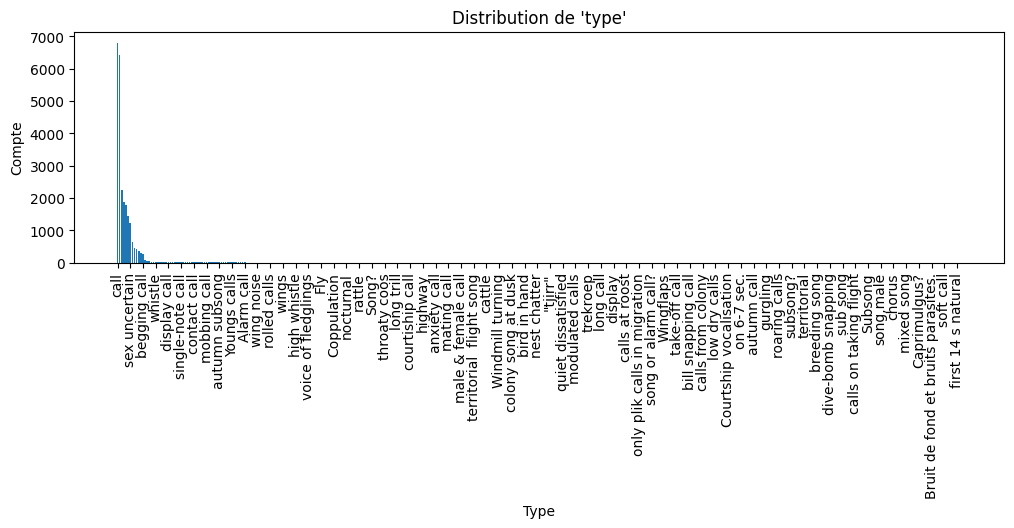

In [9]:
#
# examiner la distribution dans type
#
from itertools import islice

# calculer histogram
def type_histogram(types_, hist_dict):
    for t in types_:
        if t in hist_dict:
            hist_dict[t] += 1
        else:
            hist_dict[t] = 1

hist_dict = {}
raw_df["type"].apply(type_histogram, args=(hist_dict,))

# convertir en Series pandas (simplifie extraction statistiques)
hist_df =  pd.Series(data=hist_dict.values(), index=hist_dict.keys())

# afficher quelques stats
print("Stat. generale pour 'type'")
display(hist_df.describe().to_frame().T)

# afficher histogramme - ne garder que quelques lables car 
# il n'y en a trop pour etre visialise
count = len(hist_dict)

# afichage partiel des labels sur axe des x
# diagrame affiche tout par contre
step = 6

sorted_hist = sorted(hist_dict.items(), key=lambda x: x[1], reverse=True)
sorted_hist = {k:v for k, v in sorted_hist}

plt.figure(figsize=(12, 3))
plt.bar([i for i in range(count)], sorted_hist.values())

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([k for k in islice(sorted_hist.keys(), 0, count, step)], rotation=90)

plt.xlabel("Type")
plt.ylabel("Compte")
plt.title("Distribution de 'type'")
plt.show()

<div class="answer">

* Grande majorité des modalités **type** ont tres peu d'instance ; pour simplifier le projet, on rejette.

**En somme:**

* 16941 échantillons
* 12 variables. Selon les informations trouvées via l'url et un examin visuel, les variables interessantes semblent à prime abord:
    - **primary_label**: Identification de l'oiseau.
    - **latitude** & **longitude**: Coordonnés de l'enregistrement audio (gardé pour usage eventuel).
    - **filename**: Nom du fichier audio.
    - **url**: url sur informations complémentaires. Bien qu'utile, jugé non nécessaire puisque audio est deja présent dans les données et images/metadata sont aussi disponible via primary_label.
    - **common_name**: Utile pour interprétation des résultats bien que non nécessaire.
    - **rating**: Evaluation de la qualité des fichiers audio. Pourrait etre utile pour filtrer davantage.
* Les variables sont en fait des fichiers audio augmentées avec les latitudes & longitudes (données de type quantitative) et quelques metadata (donnees de type qualitative)
* La variable cible est de type qualitative.

In [10]:
#
# ne garder que les attributs d'interets
#
data_df = raw_df[[
    "common_name",
    "primary_label", 
    "latitude", 
    "longitude", 
    "rating", 
    "filename"
]]
print("Attributs d'interet")
display(data_df.head())

Attributs d'interet


,common_name,primary_label,latitude,longitude,rating,filename
0,African Bare-eyed Thrush,abethr1,4.3906,38.2788,4.0,abethr1/XC128013.ogg
1,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363501.ogg
2,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,3.5,abethr1/XC363502.ogg
3,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,5.0,abethr1/XC363503.ogg
4,African Bare-eyed Thrush,abethr1,-2.9524,38.2921,4.5,abethr1/XC363504.ogg


In [11]:
#
# explorer les valeurs manquantes
#
na_indices = data_df.isna()
na_rows = na_indices.any(axis=1)
na_num = na_rows.sum()

print(f"Quantite de valeurs manquantes: {na_num} ({na_num / data_df.shape[0] % 100:0.2f}%)")

print("Quelques valeurs manquantes")
display(data_df[na_rows].head())

Quantite de valeurs manquantes: 227 (0.01%)
Quelques valeurs manquantes


,common_name,primary_label,latitude,longitude,rating,filename
10,African Bare-eyed Thrush,abethr1,NaN,NaN,4.0,abethr1/XC585802.ogg
220,African Emerald Cuckoo,afecuc1,NaN,NaN,2.5,afecuc1/XC118454.ogg
913,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC169360.ogg
914,Barn Swallow,barswa,NaN,NaN,1.0,barswa/XC171221.ogg
916,Barn Swallow,barswa,NaN,NaN,3.0,barswa/XC171624.ogg


<div class="answer">

* Inspection dans .csv source montre bien que les valeurs sont manquantes.
* Comme il n'y en a peu, on les enlèves.

In [12]:
#
# Enlever NA
#
print("Shape avant:", data_df.shape)
valid_data_df = data_df[~na_rows]
print("Shape apres:", valid_data_df.shape)

Shape avant: (16941, 6)
Shape apres: (16714, 6)


In [13]:
#
# explorer doublons
#
dup_rows = valid_data_df.duplicated()
dup_num = dup_rows.sum()

print("Quantite de doublons:", dup_num)

Quantite de doublons: 0


<div class="answer">

* Pas de doublon.
* On extrait sampling rate et la durée des fichiers audio avant d'examiner les distributions. En effet, la solution envisagée risque d'utiliser des segments audios ce qui affecte les distributions.

In [14]:
# extraire sampling rate et duree des fichiers audios
# les resultats sont cacher; mettre FORCE_PROCESS_AUDIO_STATS a True pour recalculer
FORCE_PROCESS_AUDIO_STATS = False

filename = Path.joinpath(config.paths.DATA_RAW_DIR, "data_extended.csv")

def get_samplingrate_duration(config, filename):
    f = config.get_audio_filename(filename)

    # tester audioread vs librosa pour lecture
    # techniquement, pas besoin de tout loader pour avoir infos voulue
    # conclusion: aucune difference en terme de temps de loading MAIS
    #             sampling rate est different
    with audioread.audio_open(f) as audio_file:
        return audio_file.samplerate, \
               audio_file.duration

if FORCE_PROCESS_AUDIO_STATS or not Path(filename).is_file():
    from ffury.misc.concurrent import (
        create_dask_local_client,
        parallel_for
    )

    selected_audio = valid_data_df[:]

    def process_batch(config, batch):
        data = []
        for index, (common_name, primary_label, latitude, longitude, rating, filename) in batch:
            sr, duration = get_samplingrate_duration(config, filename)
            data.append([common_name, 
                         primary_label, 
                         latitude, 
                         longitude, 
                         rating, 
                         filename, 
                         sr, 
                         duration])
        return data

    def batch_done(data, progress, accum):
        accum.extend(data)
        progress.update(len(data))

    audio_data = []
    total = len(selected_audio)
    with create_dask_local_client(memory_limit="2GB") as client:
        with tqdm(total=total) as progress:
            parallel_for(selected_audio.iterrows(),
                         process_batch,
                         config,
                         task_completed=lambda r: batch_done(r, progress, audio_data),
                         chunk_size=10,
                         client=client)

    extended_data_df = pd.DataFrame(data=audio_data, 
                                    columns=["common_name", 
                                             "primary_label", 
                                             "latitude", 
                                             "longitude", 
                                             "rating", 
                                             "filename", 
                                             "SR", 
                                             "Duration"])
    extended_data_df.to_csv(filename, 
                         index=False)
    print("Sauvegarde", filename)
else:
    extended_data_df = pd.read_csv(filename)
    print("Reutilise", filename)

Reutilise /Users/jfgagnon/Projects/FeatheredFury/data/raw/data_extended.csv


In [15]:
# valider l'etape precedente 
# relire 100 fichiers choisi au hasard et valider duration et sampling rate
if False:
    for i in np.random.randint(0, len(extended_data_df), 100):
        row = extended_data_df.iloc[i]
        sr, duration = get_samplingrate_duration(config, row["filename"])
        assert sr == row["SR"], f"i: {row['filename']} - {sr} vs {row['SR']}"

        duration = round(duration, 4)
        duration_test = round(row["Duration"], 4)
        assert duration == duration_test, f"i: {row['filename']} - {duration} vs {duration_test}"

    print("Validation SR et duration: PASSED")

Nombre d'espèces: 264


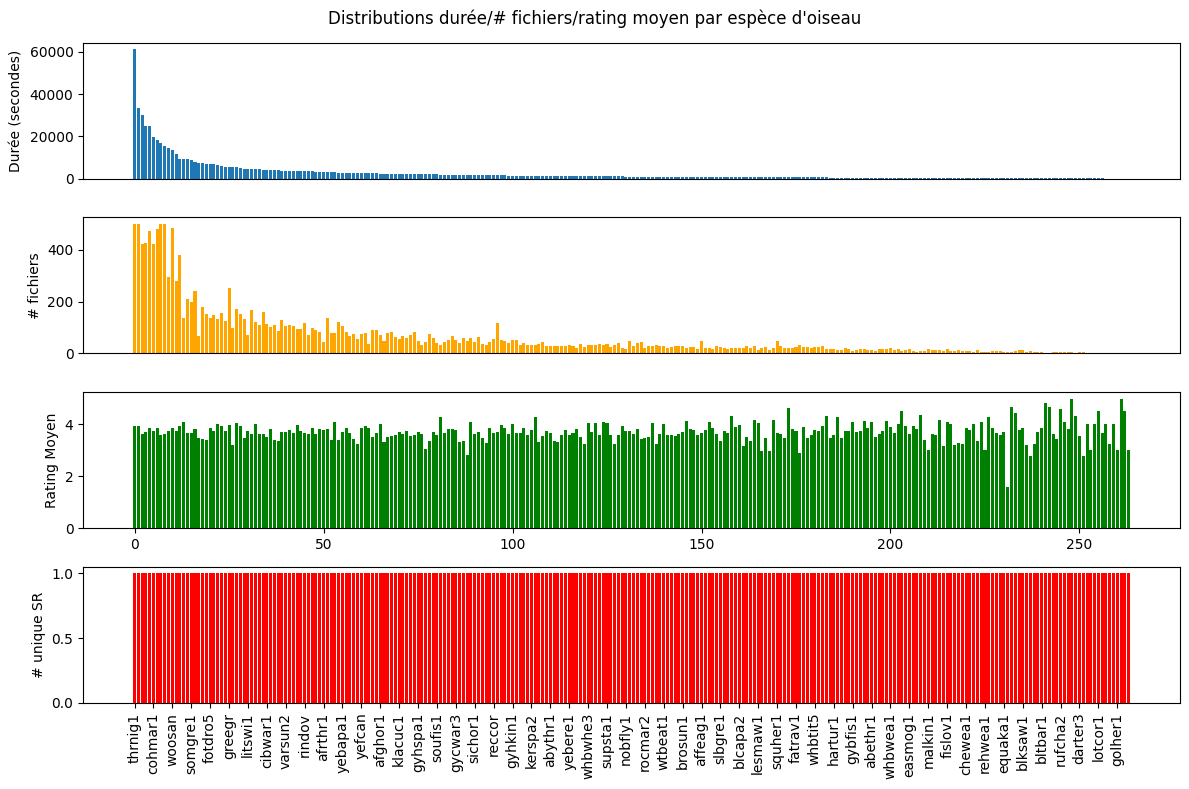

In [16]:
# examiner distributions primary_label (espece)
#
unique_bird = extended_data_df.groupby(by="primary_label")
unique_bird_count = len(unique_bird)
print("Nombre d'espèces:", unique_bird_count)

unique_bird_dist = unique_bird.agg({"Duration": ["sum", "count"], 
                                    "rating": "mean",
                                    "SR": "nunique"})
unique_bird_dist = unique_bird_dist.sort_values(by=("Duration", "sum"), 
                                                ascending=False)

total_duration = unique_bird_dist[("Duration", "sum")]
num_samples = unique_bird_dist[("Duration", "count")]
mean_rating = unique_bird_dist[("rating", "mean")]
sr_count = unique_bird_dist[("SR", "nunique")]

STEP = 5
WIDTH = 2

dist_range = range(unique_bird_count)
dist_range_step = range(0, unique_bird_count, STEP)

indices = [i for i in dist_range]
indices_step = [i for i in dist_range_step]

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.bar(indices,
        total_duration.iloc[indices])
plt.ylabel("Durée (secondes)")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(412)
plt.bar(indices,
        num_samples.iloc[indices],
        color="orange")
plt.ylabel("# fichiers")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(413)
plt.bar(indices,
        mean_rating.iloc[indices],
        color="green")
plt.ylabel("Rating Moyen")

plt.subplot(414)
plt.bar(indices,
        sr_count.iloc[indices],
        color="red")
plt.ylabel("# unique SR")

plt.gca().set_xticks(indices_step)
plt.gca().set_xticklabels([unique_bird_dist.index[i] for i in indices_step], rotation=90)

plt.suptitle("Distributions durée/# fichiers/rating moyen par espèce d'oiseau")
plt.tight_layout()
plt.show()

In [17]:
# stats sommaire par espece
#
display(unique_bird_dist.describe().T)
print("Sampling rate:", extended_data_df["SR"].unique())

count         mean          std       min         25%  \
Duration sum      264.0  2589.716288  5700.180002  7.700000  382.175000   
         count    264.0    63.310606    96.998070  1.000000   14.000000   
rating   mean     264.0     3.723870     0.378552  1.583333    3.555556   
SR       nunique  264.0     1.000000     0.000000  1.000000    1.000000   

                         50%          75%      max  
Duration sum      958.550000  2331.550000  61383.9  
         count     29.500000    70.250000    500.0  
rating   mean       3.711982     3.923789      5.0  
SR       nunique    1.000000     1.000000      1.0

Sampling rate: [32000]


<div class="answer">

* 264 correspond au nombre d'espèces attendu selon description du dataset.
* 1 seul sampling rate.
* **rating** semble couvrir uniformement toutes les espèces.
* La partie gauche de la distribution de la durée est assez differente de celle du nombre de fichiers ; elle nous apparait comme plus représentative et sera utilisée pour séparer le dataset en train, validation et test.
* Distributions durée et nombre de fichiers sont très mal balancées.

Regardons la distribution des durées.

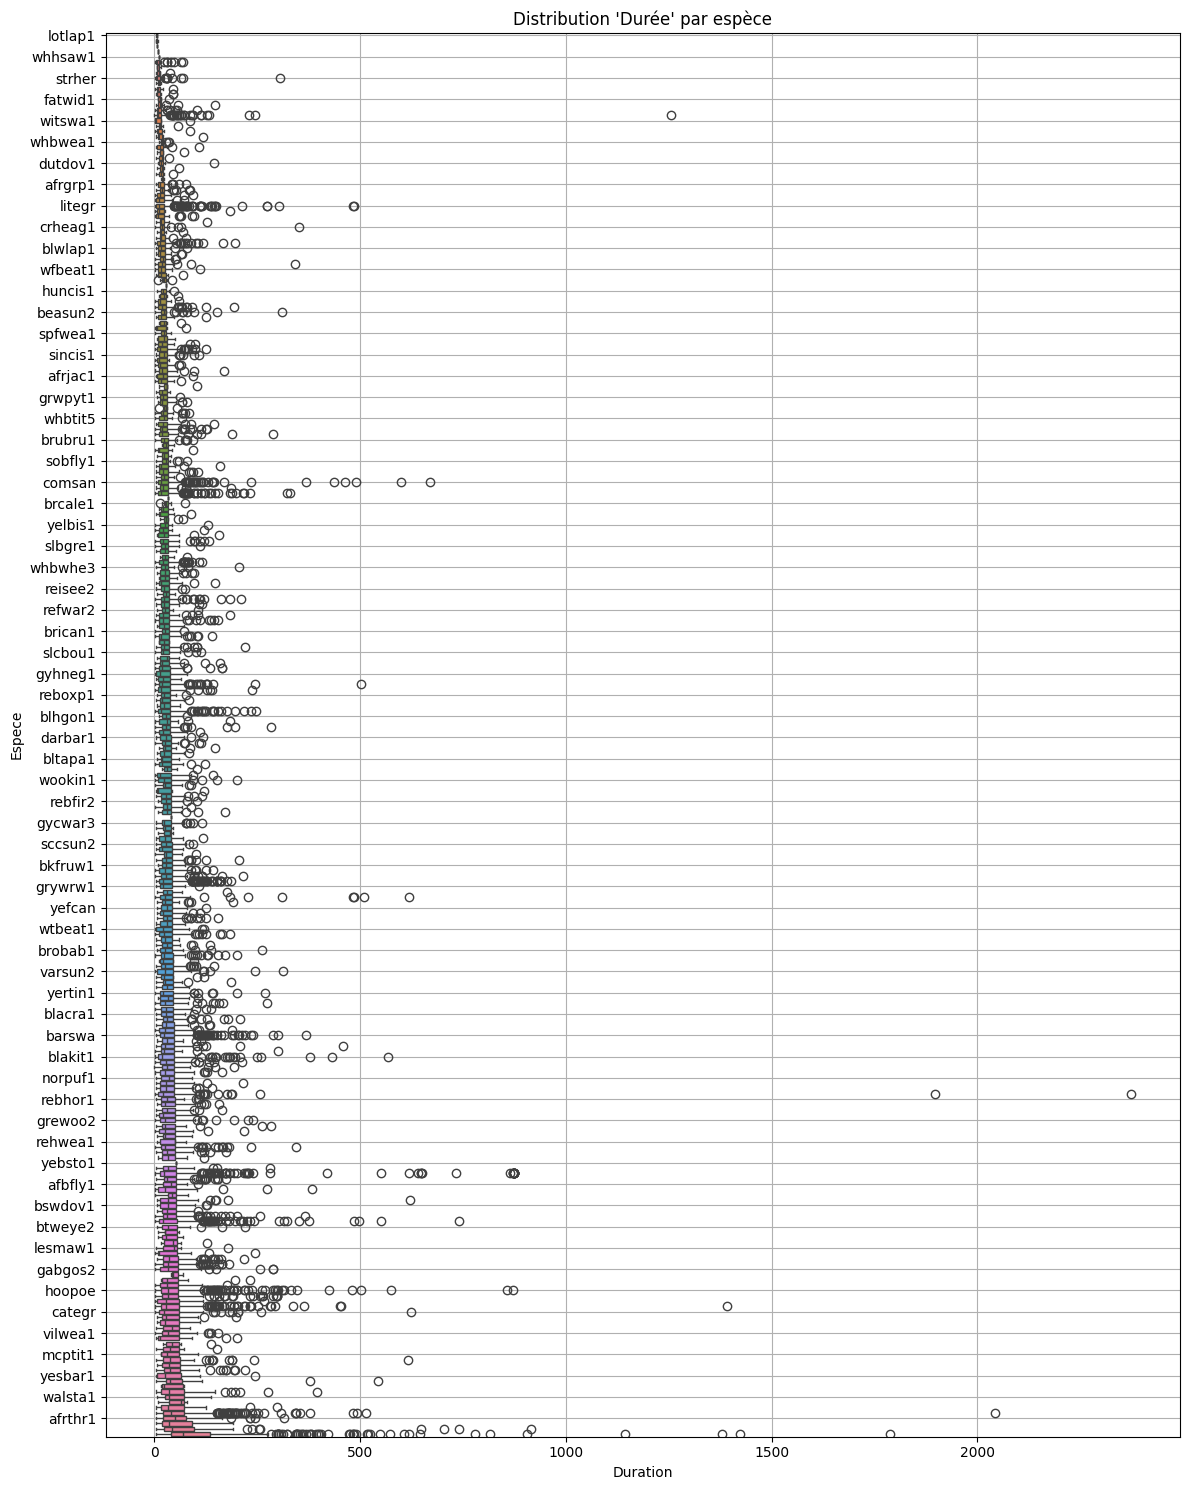

In [18]:
# distributions des durees par espece
#
duration_dict = {}
duration_sorting_dict = {}

for i, g in enumerate(unique_bird.groups):
    data = unique_bird.get_group(g)
    group = str(g)
    duration = data["Duration"]
    duration_total = duration.sum()
    duration_dict[group] = duration
    duration_sorting_dict[group] = duration.quantile(0.75)

sorted_keys = list(duration_sorting_dict.keys())
sorted_keys = sorted(sorted_keys, key=lambda k: duration_sorting_dict[k])

from collections import OrderedDict
ordered_duration_dict = OrderedDict((k, duration_dict[k]) for k in sorted_keys)

plt.figure(figsize=(12, 15))
sns.boxplot(ordered_duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par espèce")
plt.xlabel("Duration")
plt.ylabel("Espece")

STEP = 4
plt.gca().set_yticks([k for k in range(0, len(sorted_keys), STEP)])
plt.gca().set_yticklabels([k for k in sorted_keys[::STEP]])

plt.tight_layout()
plt.show()

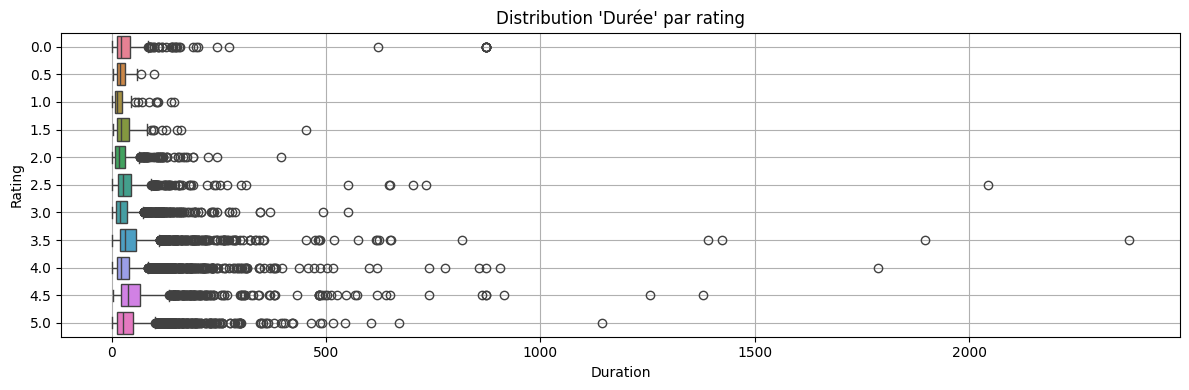

Stats sommaire par rating


rating            0.0    0.5     1.0     1.5     2.0      2.5     3.0  \
Duration Q1     12.20  11.20    6.90   11.70    8.20    14.28    9.40   
         Q2     21.15  19.70   12.00   21.60   16.45    25.95   18.10   
         Q3     41.05  30.05   23.02   40.90   30.67    45.40   35.02   
         Mean   46.22  25.13   21.88   33.22   28.33    41.41   29.16   
         Min     0.90   3.00    1.20    1.70    0.90     0.80    0.80   
         Max   873.30  99.30  145.80  452.00  395.00  2043.10  551.20   

rating             3.5      4.0      4.5      5.0  
Duration Q1      18.48    11.70    21.70    12.90  
         Q2      31.30    22.10    37.00    26.20  
         Q3      55.20    40.90    66.60    48.30  
         Mean    51.32    36.27    63.35    40.52  
         Min      1.20     0.50     2.20     0.70  
         Max   2373.50  1787.80  1380.00  1144.00

In [19]:
# distributions des durees par rating
#
ratings = extended_data_df.groupby(by="rating")

duration_dict = {}
duration_sorting_dict = {}

for i, g in enumerate(ratings.groups):
    duration_dict[str(g)] = ratings.get_group(g)["Duration"]

plt.figure(figsize=(12, 4))
sns.boxplot(duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par rating")
plt.xlabel("Duration")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

# stats generales par ratings
#
groups = ratings.agg({"Duration": [("Q1", lambda x: x.quantile(0.25)),
                                   ("Q2", lambda x: x.quantile(0.50)),
                                   ("Q3", lambda x: x.quantile(0.75)),
                                   ("Mean", lambda x: x.mean()),
                                   ("Min", lambda x: x.min()),
                                   ("Max", lambda x: x.max())]})
print("Stats sommaire par rating")
display(groups.T.round(2))

<div class="answer">

* Les distributions de durée, non obstant les outliers, semblent tout de même similaires en général.
* On remarque la présence de clips audio très long. Selon la description du dataset, la capture s'effectue dans des conditions réelles. On pourrait alors croire plus la durée est grande, plus les clips sont susceptible de contenir des éléments parasites rendant l'identification difficile. Cepandant, **rating** semble suggérer, en regardant les outliers de durée, que les long clips sont mieux cotés (**rating** > 2.5 semblent avoir plus d'outliers).

Bien que suggestif, écoutons quelques clips pour évaluer **rating**.

In [20]:
def clip_in_rating(min_rating, max_rating, min_duration=None, data_df=extended_data_df):
    r = data_df["rating"] >= min_rating
    r = r & (data_df["rating"] <= max_rating)
    if not min_duration is None:
        r = r & (data_df["Duration"] >= min_duration)
    return data_df[r]

def log_clip_in_rating(min_rating, max_rating, min_duration=None, data_df=extended_data_df):
    r = clip_in_rating(min_rating, 
                       max_rating, 
                       min_duration=min_duration, 
                       data_df=data_df)
    msg = f"Nombre de clips avec rating [{min_rating}, {max_rating}]"
    if not min_duration is None:
        msg += f" et durée >= {min_duration}"
    print(msg, ":", r.shape[0])
    return r

def sample(data_df, count):
    count = min(data_df.shape[0], count)
    return data_df.sample(n=count, axis=0, replace=False)

viz_data = log_clip_in_rating(0.0, 
                              5.0, 
                              min_duration=0.0)

Nombre de clips avec rating [0.0, 5.0] et durée >= 0.0 : 16714


In [21]:
from copy import copy
from IPython.display import Audio
from ipywidgets import Output, Layout, VBox, HBox, HTML

def melspectrogram(y, sr, **kwargs):
    # besoin de passer certains parametres entre melspectrogram()
    # et specshow() pour matcher timeline
    mel_kwargs = copy(kwargs)
    display_kwargs = {}

    if "n_fft" in kwargs:
        mel_kwargs["n_fft"] = math.ceil(kwargs["n_fft"] * sr)
        display_kwargs["n_fft"] = mel_kwargs["n_fft"]

    if "hop_length" in kwargs:
        mel_kwargs["hop_length"] = math.ceil(kwargs["hop_length"] * sr)
        display_kwargs["hop_length"] = mel_kwargs["hop_length"]

    S = rosa.feature.melspectrogram(y=y, sr=sr, **mel_kwargs)
    S_db = rosa.power_to_db(S, ref=np.max)

    return S_db, display_kwargs

def get_display_outputs(index, data_df, figsize=None, **melspectrogram_kwargs):
    filename = data_df.loc[index, "filename"]
    filename = config.get_audio_filename(filename)
    y, sr = rosa.load(filename)

    waveform = Output()
    with waveform:
        fig = plt.figure(figsize=figsize)
        rosa.display.waveshow(y,
                              sr=sr,
                              ax=plt.gca())
        plt.xlabel("")
        plt.close()

        display(fig)

    spectrogram = Output()
    with spectrogram:
        fig = plt.figure(figsize=figsize)

        S_db, display_kwargs = melspectrogram(y, sr, **melspectrogram_kwargs)
        rosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='mel',
                              sr=sr,
                              ax=plt.gca(),
                              **display_kwargs)
        plt.xlabel("")
        plt.close()

        display(fig)

    player = Output()
    with player:
        display(Audio(data=y, rate=sr))

    header = Output()
    with header:
        species = data_df.loc[index, 'common_name']
        rating = data_df.loc[index, 'rating']
        html = HTML(f"{species} - index {index} - rating {rating}")
        display(html)

    hb = HBox([waveform, spectrogram, player], 
              layout=Layout(width="100%", align_items="center"))

    vb = VBox([header, hb], 
              layout=Layout(height="100%", align_items="center", padding="10px 0 0 0"))

    return vb

def visualize_audio_from_extended_df(indices, figsize=None, **melspectrogram_kwargs):
    rows = []
    for index in indices:
        row = get_display_outputs(index,
                                  extended_data_df,
                                  figsize=figsize,
                                  **melspectrogram_kwargs)
        rows.append(row)
    display(VBox(rows))

if False:
    # visualization random de viz_data
    ids = sample(viz_data, 5)
    ids = ids.index.tolist()
else:
    # exemple de "mauvaise" qualite
    ids = [1041, 12935, 13536, 14548, 9224]

#
# aide melspectrogram: https://tinyurl.com/3vf92xvx
#
STFT_FRAME_SIZE_MS = 12.5 / 1000 # ms
STFT_WINDOW_SIZE_MS = 2 * STFT_FRAME_SIZE_MS # ms

print("Clips de 'mauvaise' qualité")
visualize_audio_from_extended_df(ids,
                                 figsize=(10, 4),
                                 n_fft=STFT_WINDOW_SIZE_MS, # ms
                                 hop_length=STFT_FRAME_SIZE_MS, # ms
                                 n_mels=128,
                                 fmin=0,
                                 fmax=8192)

Clips de 'mauvaise' qualité


In [22]:
if False:
    long_clips = log_clip_in_rating(3.5, 5.0, 1000)
    ids = sample(long_clips, 2)
    ids = ids.index.tolist()
else:
    ids = [15246, 14078]

log_clip_in_rating(0.0, 2.5);

print("Clips de longue durée")
visualize_audio_from_extended_df(ids,
                                 figsize=(10, 4),
                                 n_fft=STFT_WINDOW_SIZE_MS, # ms
                                 hop_length=STFT_FRAME_SIZE_MS, # ms
                                 n_mels=128,
                                 fmin=0,
                                 fmax=8192)

Nombre de clips avec rating [0.0, 2.5] : 2259
Clips de longue durée


<div class="answer">

* Bien que non exhaustif, les échantillons précédants suggère que **rating** est corrélé à la capacité d'identification des oiseaux. A savoir, enregistrement de bonne qualité, chant oiseau bien défini. Nous garderons **rating** >= 3.0.
* Il est plus difficile de trancher sur la durée. Un modèle de très haute qualité devrait pouvoir gérer ces clips mais dans un but de simplification, les clips de plus de 300 secondes (5 minutes) seront enlevés. Les clips trop courts sont moins utiles. La literature semble suggérer des segments audio de 3 secondes. Noter que notre manque de connaissance dans le domaine ne nous permets pas d'aller au dela de ce constat.
* Le débalancement des espèces devra être tenu en compte par les métriques lors de l'entrainement.

In [23]:
#
# filtrer le data d'interet
#
final_data = (extended_data_df["rating"] >= 3.0) & \
             (extended_data_df["Duration"] >= 3.0) & \
             (extended_data_df["Duration"] <= 300.0)
final_data_df = extended_data_df[ final_data ].copy()
final_data_df.drop(columns=["rating", "SR"], inplace=True, errors="ignore")

print("# elements avant filtrage:", extended_data_df.shape[0])
print("# elements apres filtrage:", final_data_df.shape[0])
print("Attributs retenus:\n", final_data_df.columns.values)

print()

total_duration = final_data_df["Duration"][final_data].sum()

hours = total_duration / 3600
minutes, hours = math.modf(hours)
seconds, minutes = math.modf(minutes * 60)
seconds = seconds * 60

hours = int(hours)
minutes = int(minutes)
seconds = int(seconds)

print(f"Duree total apres filtrage:  {hours}h {minutes}m {seconds}s")

print()

# sauvegarde du traitement
filename = config.get_csv_filename(DatasetType.EXPLORED)
print("Sauvegarde de l'exploration:", filename)
final_data_df.to_csv(filename, index=False)

# elements avant filtrage: 16714
# elements apres filtrage: 14086
Attributs retenus:
 ['common_name' 'primary_label' 'latitude' 'longitude' 'filename'
 'Duration']

Duree total apres filtrage:  147h 19m 32s

Sauvegarde de l'exploration: /Users/jfgagnon/Projects/FeatheredFury/data/data_explored.csv
